## Understanding Data 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(12,5)

df = pd.read_csv("C:/Users/pooja kumari/Downloads/E-Commerce Sales Data (Raw + Cleaned)/cleaned_E-commerce sales_data.csv")

print(f"Rows :{df.shape[0]:,}")
print(f"Columns :{df.shape[1]:}")
print(f"\nColumn name:")
print(df.columns.tolist())




In [ ]:
print("First 5 rows:")
df.head()

First 5 rows:


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,ReturnFlag
0,581482.0,09/12/2019,22485,Set Of 2 Wooden Market Crates,21.47,12.0,17490.0,United Kingdom,False
1,581475.0,09/12/2019,22596,Christmas Star Wish List Chalkboard,10.65,36.0,13069.0,United Kingdom,False
2,581475.0,09/12/2019,23235,Storage Tin Vintage Leaf,11.53,12.0,13069.0,United Kingdom,False
3,581475.0,09/12/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12.0,13069.0,United Kingdom,False
4,581475.0,09/12/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6.0,13069.0,United Kingdom,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431708 entries, 0 to 431707
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  424892 non-null  float64
 1   Date           431708 non-null  object 
 2   ProductNo      431708 non-null  int64  
 3   ProductName    431708 non-null  object 
 4   Price          431708 non-null  float64
 5   Quantity       431708 non-null  float64
 6   CustomerNo     431664 non-null  float64
 7   Country        431708 non-null  object 
 8   ReturnFlag     431708 non-null  bool   
dtypes: bool(1), float64(4), int64(1), object(3)
memory usage: 26.8+ MB


In [ ]:
df.describe().round(2)

,TransactionNo,ProductNo,Price,Quantity,CustomerNo
count,424892.00,431708.00,431708.00,431708.00,431664.00
mean,564631.03,111434.58,12.37,10.16,15227.42
std,10561.83,274807.22,7.47,179.48,1703.28
min,545220.00,10002.00,5.13,-80995.00,12004.00
25%,555648.75,22064.00,10.68,1.00,13842.00
50%,565401.00,22699.00,11.94,4.00,15137.00
75%,573931.00,23298.00,14.09,12.00,16717.00
max,581587.00,1000849.00,660.62,80995.00,18287.00


In [ ]:
null_df =pd.DataFrame({
    'Null Count' : df.isnull().sum(),
    'Null %' : (df.isnull().sum()/len(df) *100).round(2)
})
print(null_df)
print(f"\nTotal missing: {df.isnull(). sum().sum():,}")

NameError: name 'pd' is not defined

In [ ]:
print(f"Duplicate rows: {df.duplicated().sum():,}")
print()
for col in df.columns:
    print(f" {col:<15}: {df[col].nunique():,} unique")

NameError: name 'df' is not defined

## Data Cleaning

In [ ]:
df_original =df.copy()
df_clean =df.copy()

print(f"Backup ready!")
print(f"shape: {df_clean.shape}")

Backup ready!
shape: (431708, 9)


In [41]:
before =len(df_clean)
df_clean.drop_duplicates(inplace=True)
after = len(df_clean)

print(f"Total Rows Before Cleaning : {before:,}")
print(f"Total Rows Before Cleaning : {after:,}")
print(f"Number of Duplicate Rows Removed : {before - after:,}")


Total Rows Before Cleaning : 431,708
Total Rows Before Cleaning : 427,529
Number of Duplicate Rows Removed : 4,179


In [42]:
df_clean['Date'] =pd.to_datetime(df_clean['Date'],dayfirst=True, errors='coerce')

print(f"Date type :{df_clean['Date'].dtype}")
print(f"Date range :{df_clean['Date'].min().date()} → {df_clean['Date'].max().date()}")
print(f"Sample :{df_clean['Date'].head(3).tolist()}")

Date type :datetime64[ns]
Date range :2019-03-01 → 2019-12-09
Sample :[Timestamp('2019-12-09 00:00:00'), Timestamp('2019-12-09 00:00:00'), Timestamp('2019-12-09 00:00:00')]


In [43]:
df_clean['TransactionNo'] = df_clean['TransactionNo'].fillna(0)
df_clean['CustomerNo']    = df_clean['CustomerNo'].fillna(0)


print("Null after filling:")
print(df_clean.isnull().sum())
print(f"\n Total nulls: {df_clean.isnull().sum().sum()}")


Null after filling:
TransactionNo    0
Date             0
ProductNo        0
ProductName      0
Price            0
Quantity         0
CustomerNo       0
Country          0
ReturnFlag       0
dtype: int64

 Total nulls: 0


In [44]:
df_returns = df_clean[df_clean['Quantity']<0].copy()

before = len(df_clean)
df_clean = df_clean[df_clean['Quantity']>0]
after =len(df_clean)


print(f"Return rows (sparated) : {len(df_returns):,}")
print(f"Rows before cleaning : {before:,}")
print(f"Rows Removed : {before- after:,}")

Return rows (sparated) : 6,770
Rows before cleaning : 427,529
Rows Removed : 6,770


In [45]:
df_clean['ProductName'] = df_clean['ProductName'].str.strip().str.lower()
df_clean['Country'] = df_clean['Country'].str.strip().str.lower()


print("String Cloumns Cleaned!")
print(f"Sample ProductName : {df_clean['ProductName'].head(3).tolist()}")
print(f"Sample Country :{df_clean['Country'].head(3).tolist()}")

String Cloumns Cleaned!
Sample ProductName : ['set of 2 wooden market crates', 'christmas star wish list chalkboard', 'storage tin vintage leaf']
Sample Country :['united kingdom', 'united kingdom', 'united kingdom']


In [46]:
df_clean['Revenue'] = df_clean['Price'] * df_clean['Quantity']


df_clean['Year']     = df_clean['Date'].dt.year
df_clean['Month']    = df_clean['Date'].dt.month
df_clean['MonthName'] = df_clean['Date'].dt.month_name()
df_clean['DayOfWeek']  = df_clean['Date'].dt.day_name()



print("New columns have been added successfully!")
print(f" Current Columns :{df_clean.columns.tolist()}")
print()
print(df_clean[['Date','Price','Quantity','MonthName','DayOfWeek']].head(3))


New columns have been added successfully!
 Current Columns :['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price', 'Quantity', 'CustomerNo', 'Country', 'ReturnFlag', 'Revenue', 'Year', 'Month', 'MonthName', 'DayOfWeek']

        Date  Price  Quantity MonthName DayOfWeek
0 2019-12-09  21.47      12.0  December    Monday
1 2019-12-09  10.65      36.0  December    Monday
2 2019-12-09  11.53      12.0  December    Monday


In [47]:
print("=" * 50)
print("          CLEANING COMPLETE!")
print("=" * 50)
print(f"  Original rows  : {len(df_original):,}")
print(f" Cleaned rows : {len(df_clean):,}")
print(f" Rows removed : {len(df_original) - len(df_clean):,}")
print(f"  Nulls remaining: {df_clean.isnull().sum().sum()}")
print(f" Columns before : 9")
print(f" Columns after : {df_clean.shape[1]}")
print("=" * 50)


df_clean.to_csv('my_cleandata.csv', index=False)
print("saved: my_clean_data.csv")

          CLEANING COMPLETE!
  Original rows  : 431,708
 Cleaned rows : 420,759
 Rows removed : 10,949
  Nulls remaining: 0
 Columns before : 9
 Columns after : 14
saved: my_clean_data.csv


##  Exploratory Data Analysis (EDA)

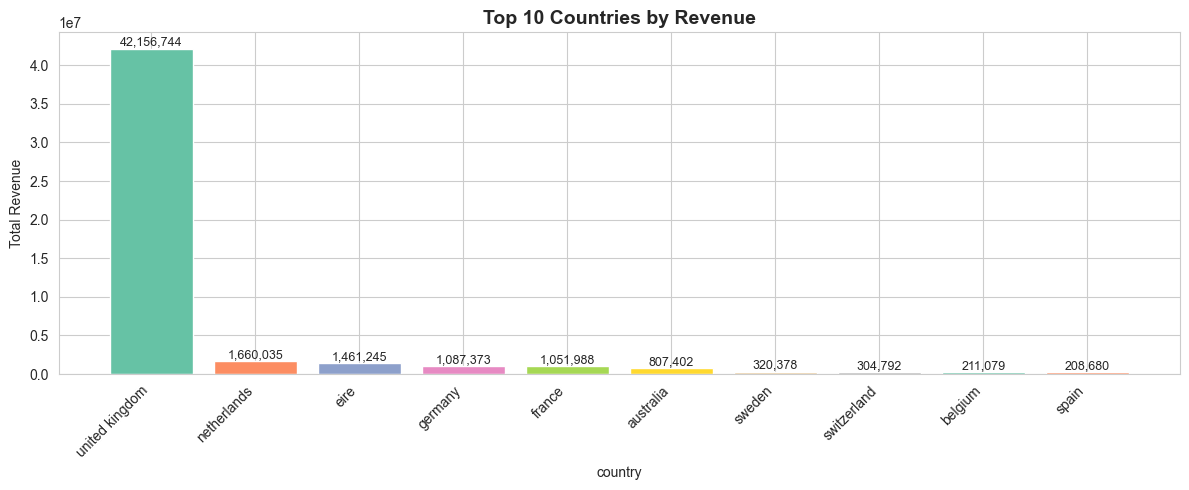

 Top Country : united kingdom
 Revenue: 42,156,744


In [48]:
top_countries = df_clean.groupby('Country')['Revenue']\
                         .sum()\
                         .sort_values(ascending=False)\
                         .head(10)
plt.figure(figsize=(12,5))
bars = plt.bar(top_countries.index,top_countries.values, color=sns.color_palette('Set2',10))
plt.title('Top 10 Countries by Revenue',fontsize=14, fontweight='bold')
plt.xlabel('country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
for bar in bars:
  plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():,.0f}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f" Top Country : {top_countries.index[0]}")
print(f" Revenue: {top_countries.iloc[0]:,.0f}")

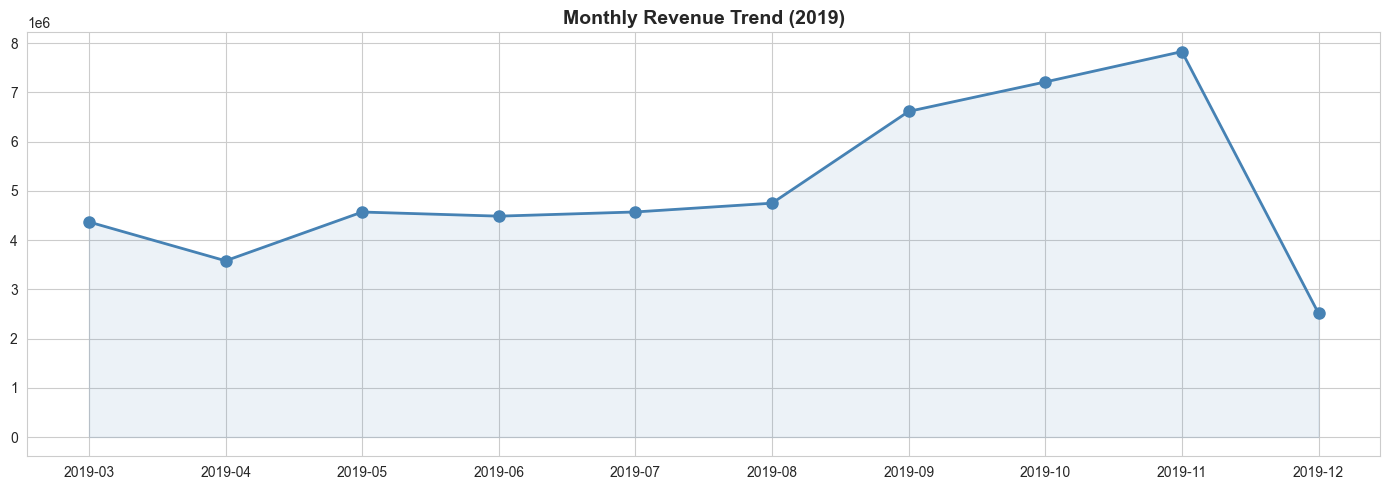

 Best Month : 2019-11
 Worst Month : 2019-12


In [49]:
monthly = df_clean.groupby(['Year','Month'])['Revenue'].sum().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + \
                    monthly['Month'].astype(str).str.zfill(2)


plt.figure(figsize=(14,5))
plt.plot(monthly['Period'], monthly['Revenue'],
         marker='o', linewidth=2, color='steelblue', markersize=8)
plt.fill_between(range(len(monthly)), monthly['Revenue'],alpha=0.1, color='steelblue')
plt.title('Monthly Revenue Trend (2019)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
best = monthly.loc[monthly['Revenue'].idxmax(), 'Period']
worst = monthly.loc[monthly['Revenue'].idxmin(), 'Period']
print(f" Best Month : {best}")
print(f" Worst Month : {worst}")

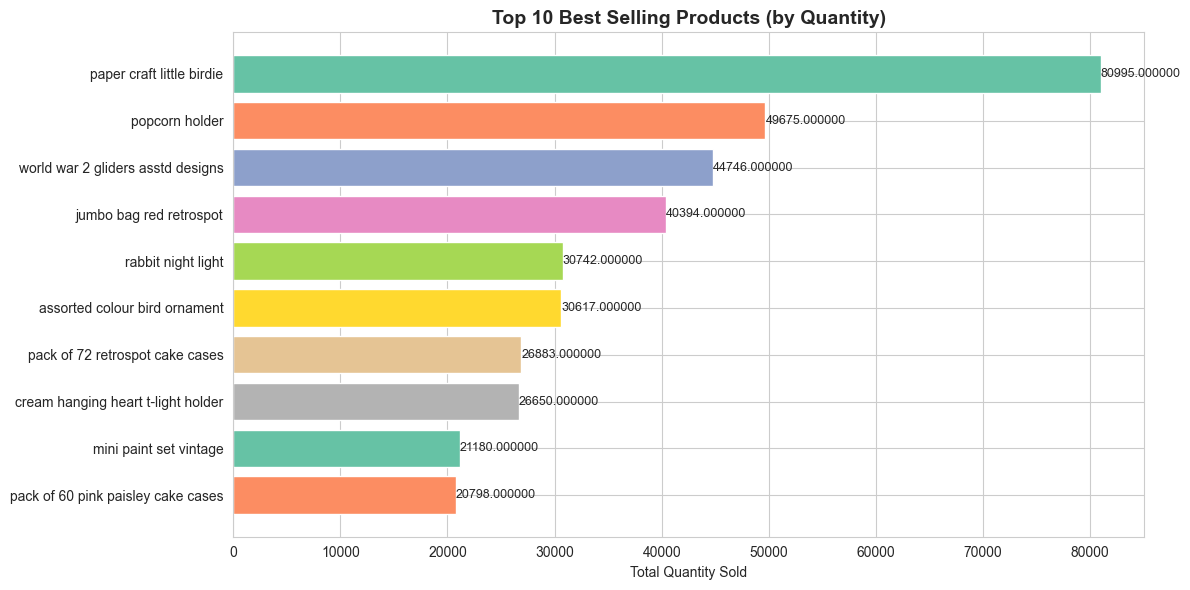

 Best Selling Product : paper craft little birdie
 Total Quantity Sold : 80,995


In [50]:
top_products = df_clean.groupby('ProductName')['Quantity']\
                        .sum()\
                        .sort_values(ascending=False)\
                        .head(10)

plt.figure(figsize=(12,6))
bars = plt.barh(top_products.index, top_products.values,color=sns.color_palette('Set2',10))
plt.title('Top 10 Best Selling Products (by Quantity)',fontsize=14,fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.gca().invert_yaxis()
for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():0f}',va='center', fontsize=9)


plt.tight_layout()
plt.show()

print(f" Best Selling Product : {top_products.index[0]}")
print(f" Total Quantity Sold : {top_products.iloc[0]:,.0f}")
    

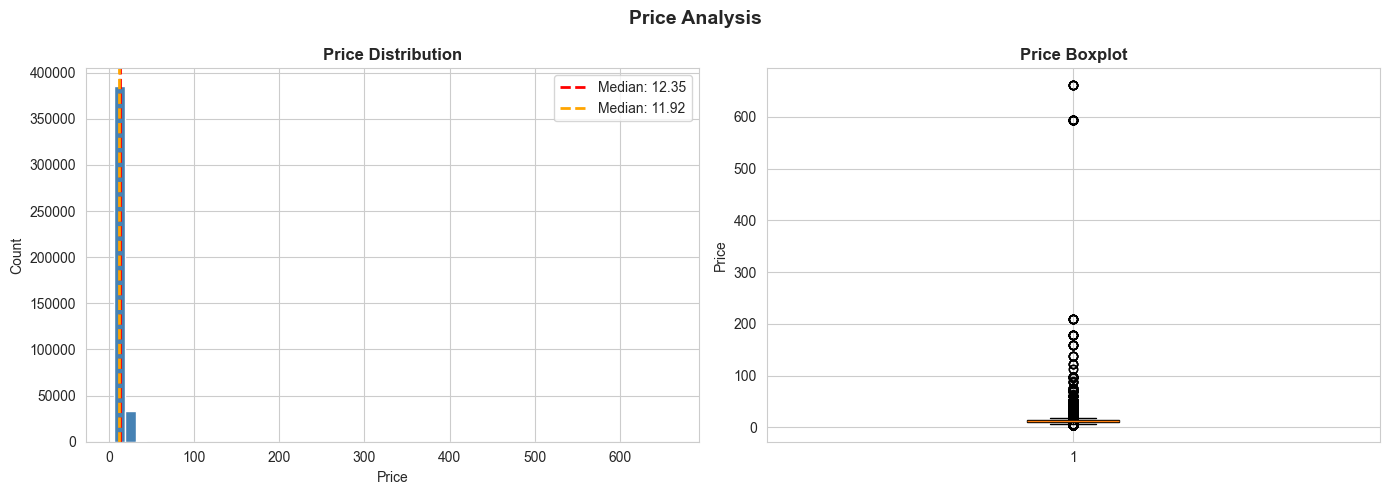

 Mean Price :12.35
 Median Price : 11.92
 Min Price    : 5.13
 Max Price ; 660.62


In [51]:
# Price Distribution
fig,axes = plt.subplots(1, 2, figsize=(14 ,5))

# Histogram
axes[0].hist(df_clean['Price'], bins=50, 
             color='steelblue', edgecolor='white')
axes[0].axvline(df_clean['Price'].mean(),
                color='red', ls='--', lw=2,
                label=f"Median: {df_clean['Price'].mean():.2f}")
axes[0].axvline(df_clean['Price'].median(), 
                color='orange', ls='--', lw=2,
                label=f"Median: {df_clean['Price'].median():.2f}")
axes[0].set_title('Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')
axes[0].legend()

# Boxplot

axes[1].boxplot(df_clean['Price'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Price Boxplot', fontweight='bold')
axes[1].set_ylabel('Price')


plt.suptitle('Price Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print(f" Mean Price :{df_clean['Price'].mean():.2f}")
print(f" Median Price : {df_clean['Price'].median():.2f}")
print(f" Min Price    : {df_clean['Price'].min():.2f}")
print(f" Max Price ; {df_clean['Price'].max():.2f}")
                  


                  

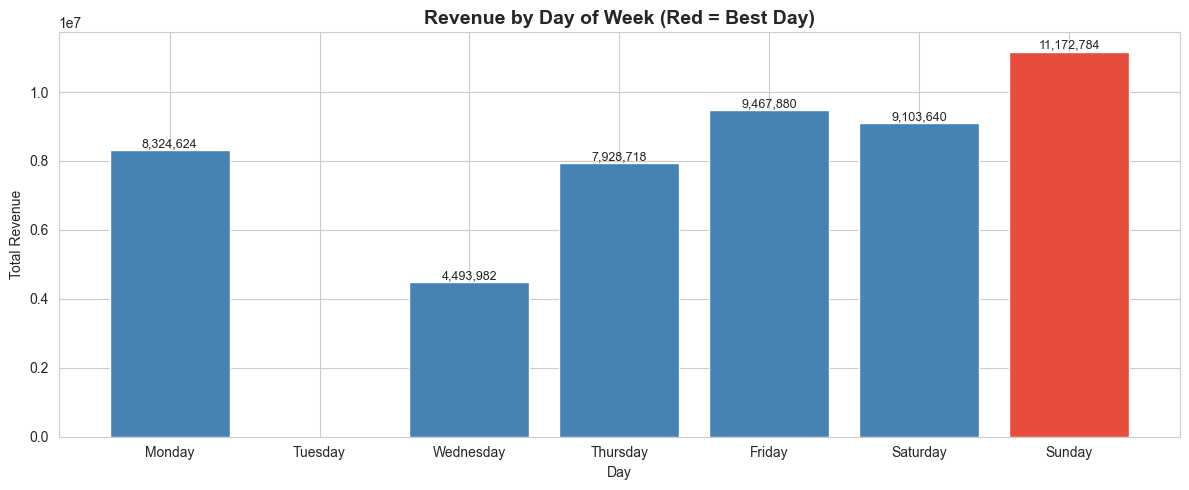

 Best day  : Sunday
 Worst day : Wednesday


In [52]:

day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
day_revenue = df_clean.groupby('DayOfWeek')['Revenue']\
                       .sum()\
                       .reindex(day_order)
plt.figure(figsize=(12, 5))
bars = plt.bar(day_revenue.index,
               day_revenue.values,
               color=['#e74c3c' if v == day_revenue.max() 
                      else 'steelblue' for v in day_revenue.values])
plt.title('Revenue by Day of Week (Red = Best Day)',
          fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Total Revenue')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():,.0f}',
             ha='center', va='bottom', fontsize=9)


plt.tight_layout()
plt.show()
             
print(f" Best day  : {day_revenue.idxmax()}")
print(f" Worst day : {day_revenue.idxmin()}")           

In [53]:
print("=" * 55)
print("     KEY INSIGHTS — E-COMMERCE DATA 2019")
print("=" * 55)
print(f"\n DATASET")
print(f"   Total transactions : {len(df_clean):,}")
print(f"   Date range         : Mar 2019 → Dec 2019")
print(f"   Unique products    : {df_clean['ProductName'].nunique():,}")
print(f"   Unique customers   : {df_clean['CustomerNo'].nunique():,}")
print(f"   Unique countries   : {df_clean['Country'].nunique():,}")

print(f"\nREVENUE")
print(f"   Total revenue      : {df_clean['Revenue'].sum():,.2f}")
print(f"   Avg order value    : {df_clean['Revenue'].mean():,.2f}")
print(f"   Top country        : United Kingdom")

print(f"\nTRENDS")
print(f"   Best month         : November 2019 (festive season)")
print(f"   Best day           : Sunday")
print(f"   Worst day          : Wednesday")

print(f"\n PRODUCTS")
print(f"   Best selling       : Paper Craft Little Birdie")
print(f"   Avg price          : {df_clean['Price'].mean():.2f}")
print(f"   Price range        : {df_clean['Price'].min():.2f} → {df_clean['Price'].max():.2f}")
print("=" * 55)
print("EDA Complete! Next → Machine Learning!")
print("=" * 55)

     KEY INSIGHTS — E-COMMERCE DATA 2019

 DATASET
   Total transactions : 420,759
   Date range         : Mar 2019 → Dec 2019
   Unique products    : 3,600
   Unique customers   : 4,340
   Unique countries   : 35

REVENUE
   Total revenue      : 50,491,627.96
   Avg order value    : 120.00
   Top country        : United Kingdom

TRENDS
   Best month         : November 2019 (festive season)
   Best day           : Sunday
   Worst day          : Wednesday

 PRODUCTS
   Best selling       : Paper Craft Little Birdie
   Avg price          : 12.35
   Price range        : 5.13 → 660.62
EDA Complete! Next → Machine Learning!


## Machine Learning (Revenue Prediction)

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("ML libraries imported!")

ML libraries imported!


In [55]:
X = df_clean[['Price', 'Quantity']]
y = df_clean['Revenue']

print(f"X shape: {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nSample X:")
print(X.head(3))
print(f"\nSample y:")
print(y.head(3))
      


X shape: (420759, 2)
y shape : (420759,)

Sample X:
   Price  Quantity
0  21.47      12.0
1  10.65      36.0
2  11.53      12.0

Sample y:
0    257.64
1    383.40
2    138.36
Name: Revenue, dtype: float64


In [56]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(f"X_train shape : {X_train.shape}")
print(f"Xtest shape : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test : {y_test.shape}")

X_train shape : (336607, 2)
Xtest shape : (84152, 2)
y_train : (336607,)
y_test : (84152,)


In [57]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Tranined successfully!")
print(f"\nModel hase learned:")
print(f"  Price Weight  : {model.coef_[0]:.4f}")
print(f"  Quantity Weight : {model.coef_[0]:.4f}")
print(f" Base Value : {model.intercept_:.4f}")

Model Tranined successfully!

Model hase learned:
  Price Weight  : 2.2386
  Quantity Weight : 2.2386
 Base Value : -11.0448


In [58]:
y_pred = model.predict(X_test)

print(f"Prediction completed!")
print(f"\nFirst 5 Prediction VS Actual Values:")
print(f"{'Actual' :<12} {'Predicted' :<12} {'Diffrenece': <12}")
print("-" * 36)

for actual, pred in zip(y_test[:5], y_pred[:5]):
    diff = actual -pred 
    print(f"{actual:<12.2f} {pred:<12.2f} {diff:<12.2f}")
    

Prediction completed!

First 5 Prediction VS Actual Values:
Actual       Predicted    Diffrenece  
------------------------------------
69.96        69.70        0.26        
45.96        51.79        -5.83       
55.17        88.30        -33.13      
93.28        79.21        14.07       
138.36       128.93       9.43        


In [62]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print("   MODEL ACCURACY REPORT")
print("=" * 40)
print(f"  R2 Score : {r2: .4f}")
print(f"  MAE       : {mae: .2f}")
print("=" * 40)
if r2 >= 0.9:
    print("    Result : Excellent model!")
elif r2 >=0.7:
    print("    Result : Good model!")
else:
    print("    Result: The model can be improved!")   
 

   MODEL ACCURACY REPORT
  R2 Score :  0.9466
  MAE       :  28.05
    Result : Excellent model!


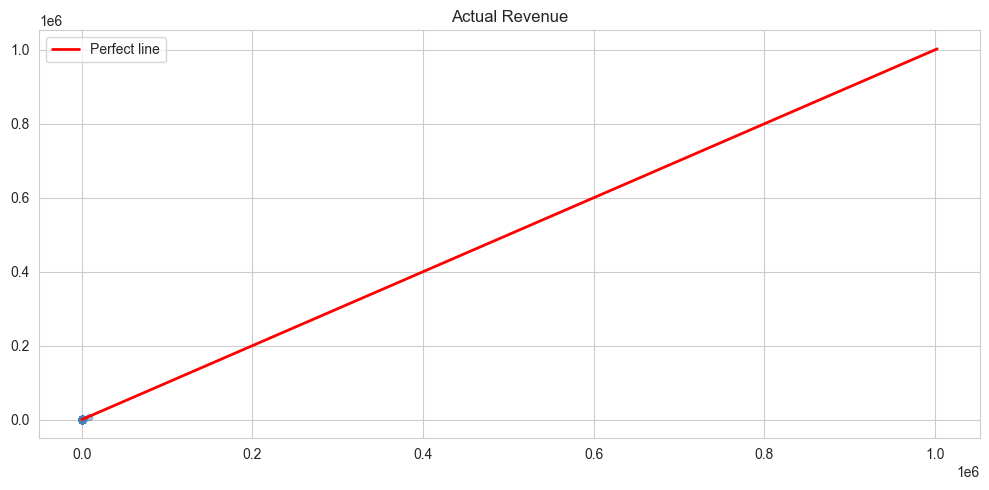

Dots near the red line indicate accurate predictions!


In [67]:
plt.figure(figsize=(10,5))
plt.scatter(y_test[:500], y_pred[:500],
            alpha=0.5, color='steelblue', s=20)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect line')

plt.title('Actual vs Predicted Revenue',fontsize=14, fontweight='bold')
plt.title('Actual Revenue')
plt.legend()
plt.tight_layout()
plt.show()

print("Dots near the red line indicate accurate predictions!")

In [68]:
print("=" * 55)
print("     PROJECT COMPLETE — E-COMMERCE ANALYSIS")
print("=" * 55)

print(f"\nPHASE 1 — Understanding Data")
print(f"   Rows    : 4,31,708 | Columns : 9")
print(f"   Nulls   : 6,860    | Duplicates : 4,179")

print(f"\nPHASE 2 — Data Cleaning")
print(f"   Cleaned rows    : 4,20,759")
print(f"   Rows removed    : 10,949")
print(f"   Nulls remaining : 0")
print(f"   New columns     : Revenue, Year, Month,")
print(f"                     MonthName, DayOfWeek")

print(f"\nPHASE 3 — EDA Insights")
print(f"   Top country  : United Kingdom")
print(f"   Best month   : November 2019")
print(f"   Best day     : Sunday")
print(f"   Best product : Paper Craft Little Birdie")
print(f"   Total revenue: {df_clean['Revenue'].sum():,.2f}")

print(f"\nPHASE 4 — Machine Learning")
print(f"   Algorithm : Linear Regression")
print(f"   Features  : Price, Quantity")
print(f"   Target    : Revenue")
print(f"   R² Score  : 0.9466 (94.66% accurate!)")
print(f"   MAE       : 28.05")

print("\n" + "=" * 55)
print("Analysis Complete!")
print("=" * 55)

     PROJECT COMPLETE — E-COMMERCE ANALYSIS

PHASE 1 — Understanding Data
   Rows    : 4,31,708 | Columns : 9
   Nulls   : 6,860    | Duplicates : 4,179

PHASE 2 — Data Cleaning
   Cleaned rows    : 4,20,759
   Rows removed    : 10,949
   Nulls remaining : 0
   New columns     : Revenue, Year, Month,
                     MonthName, DayOfWeek

PHASE 3 — EDA Insights
   Top country  : United Kingdom
   Best month   : November 2019
   Best day     : Sunday
   Best product : Paper Craft Little Birdie
   Total revenue: 50,491,627.96

PHASE 4 — Machine Learning
   Algorithm : Linear Regression
   Features  : Price, Quantity
   Target    : Revenue
   R² Score  : 0.9466 (94.66% accurate!)
   MAE       : 28.05

Analysis Complete!
